In [27]:
import pandas as pd
import numpy as np

import pickle

In [29]:
# Load lr model
model_save_path = '../model_generators/lr/models/lr_model.pkl'
with open(model_save_path, 'rb') as f:
    lr = pickle.load(f)
print("Loaded model from", model_save_path)

Loaded model from ../model_generators/lr/models/lr_model.pkl


In [30]:
# Function to load the KFold = 5 normalized data
def load_kfold_data(fold):
    train = pd.read_csv(f'../dataset_generators/datasets/{fold}_train_normalized.csv')
    test = pd.read_csv(f'../dataset_generators/datasets/{fold}_test_normalized.csv')
    return train, test

In [31]:
# Function to use model to predict fantasy points for all weeks in final_df_with_lags, keeping 'player_id' for mapping back to player names later
def predict_fantasy_points(model):
    """
    Predict fantasy points for each player's next game using the trained model.
    
    Args:
        model: Trained XGBoost model
        final_df_with_lags: DataFrame containing player stats with lagged features
        
    Returns:
        numpy.array: Predicted fantasy points for each player
    """
    # Concatenate all test sets
    for fold in range(5):
        _, test = load_kfold_data(fold)
        if fold == 0:
            all_test = test
        else:
            all_test = pd.concat([all_test, test], ignore_index=True)
            
    test = all_test

    X_test = test.iloc[:, 12:].drop(columns=['fantasy_points'])

    # Make predictions
    predicted_fantasy_points = model.predict(X_test)

    test['predicted_fantasy_points'] = predicted_fantasy_points

    return test[['player_id', 'player_name', 'position_group', 'team', 'season', 'week', 'fantasy_points', 'predicted_fantasy_points']]

# Predict fantasy points for next week using the last trained model
predicted_fantasy_points = predict_fantasy_points(lr)
predicted_fantasy_points.head()

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,15.835396
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.008777
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,15.305389
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,14.019479
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,15.110786


In [32]:
# Remove duplicate rows where player_name, season, and week values are the same, keeping the first occurrence
predicted_fantasy_points = predicted_fantasy_points.drop_duplicates(subset=['player_name', 'season', 'week'], keep='first')

# Show the cleaned DataFrame
predicted_fantasy_points

,player_id,player_name,position_group,team,season,week,fantasy_points,predicted_fantasy_points
0,00-0007091,M.Hasselbeck,QB,IND,2015,5,16.22,15.835396
1,00-0007091,M.Hasselbeck,QB,IND,2015,12,20.30,14.008777
2,00-0007091,M.Hasselbeck,QB,IND,2015,13,4.86,15.305389
3,00-0010346,P.Manning,QB,DEN,2015,8,11.60,14.019479
4,00-0010346,P.Manning,QB,DEN,2015,10,-6.60,15.110786
...,...,...,...,...,...,...,...,...
60964,00-0039919,R.Odunze,WR,CHI,2024,6,4.00,5.819764
60965,00-0039919,R.Odunze,WR,CHI,2024,8,5.40,5.236179
60966,00-0039919,R.Odunze,WR,CHI,2024,13,2.50,5.501627
60967,00-0039919,R.Odunze,WR,CHI,2024,14,16.20,6.006732


In [33]:
# Save the predictions to a CSV file
predicted_fantasy_points.to_csv('../predictions/lr_predictions.csv', index=False)

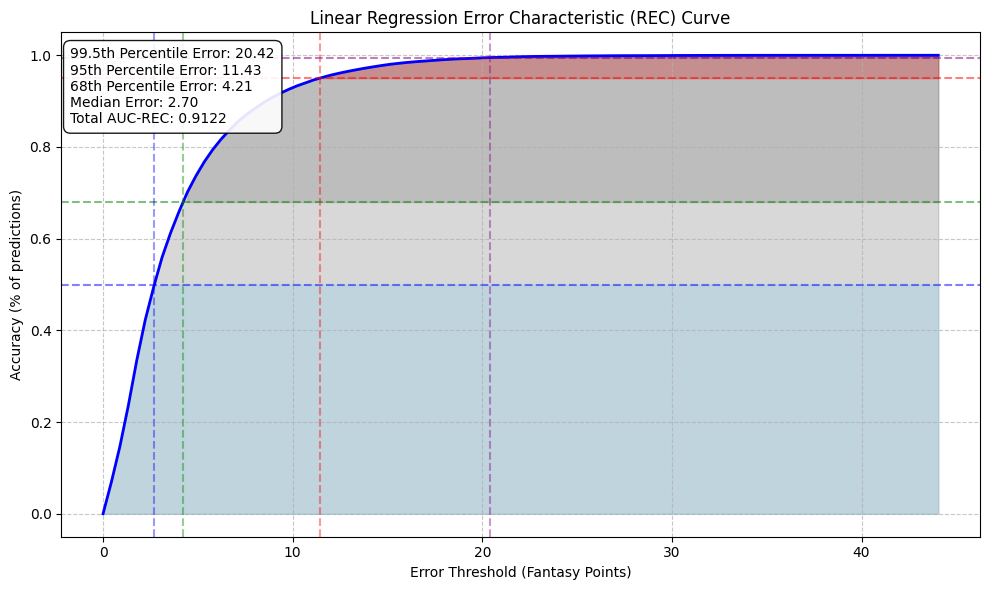

99.5th Percentile Error: 20.42 fantasy points
95th Percentile Error: 11.43 fantasy points
68th Percentile Error: 4.21 fantasy points
Median Error: 2.70 fantasy points
Total AUC-REC: 0.9122


In [36]:
import matplotlib.pyplot as plt

# Function for Regression Error Characteristic (REC) Curves
def plot_rec_curve(predicted_fantasy_points):
    predicted_fantasy_points = predicted_fantasy_points.copy()
    
    # Calculate the absolute errors
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['predicted_fantasy_points'] - predicted_fantasy_points['fantasy_points']
    predicted_fantasy_points['absolute_error'] = predicted_fantasy_points['absolute_error'].abs()
    
    # Calculate absolute errors
    errors = predicted_fantasy_points['absolute_error'].values
    
    # Create threshold values from 0 to max error
    thresholds = np.linspace(0, max(errors), 100)
    
    # Calculate accuracy for each threshold
    accuracies = [np.mean(errors <= threshold) for threshold in thresholds]
    
    # Plot REC curve
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, accuracies, 'b-', linewidth=2)
    plt.xlabel('Error Threshold (Fantasy Points)')
    plt.ylabel('Accuracy (% of predictions)')
    plt.title('Linear Regression Error Characteristic (REC) Curve')
    
    # Fill area under the curve
    plt.fill_between(thresholds, np.zeros_like(thresholds), accuracies, alpha=0.3, color='grey')
    
    # Fill 99.5th Percentile Error with different color
    percentile_99_5 = np.percentile(errors, 99.5)
    accuracy_99_5 = np.mean(errors <= percentile_99_5)
    plt.axvline(x=percentile_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Error: {percentile_99_5:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_99_5, color='purple', linestyle='--', label=f'99.5th Percentile Accuracy: {accuracy_99_5:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 99.5th percentile (99.5% and above)
    plt.fill_between(thresholds, accuracy_99_5, accuracies, where=(thresholds >= percentile_99_5), color='purple', alpha=0.3, label='99.5% Accuracy Region')
    
    # Fill 95th Percentile Error with different color
    percentile_95 = np.percentile(errors, 95)
    accuracy_95 = np.mean(errors <= percentile_95)
    plt.axvline(x=percentile_95, color='red', linestyle='--', label=f'95th Percentile Error: {percentile_95:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_95, color='red', linestyle='--', label=f'95th Percentile Accuracy: {accuracy_95:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 95th percentile (95% and above)
    plt.fill_between(thresholds, accuracy_95, accuracies, where=(thresholds >= percentile_95), color='red', alpha=0.3, label='95% Accuracy Region')

    # Fill 68th Percentile Error with different color
    percentile_68 = np.percentile(errors, 68)
    accuracy_68 = np.mean(errors <= percentile_68)
    plt.axvline(x=percentile_68, color='green', linestyle='--', label=f'68th Percentile Error: {percentile_68:.2f}', alpha=0.4)
    plt.axhline(y=accuracy_68, color='green', linestyle='--', label=f'68th Percentile Accuracy: {accuracy_68:.2f}', alpha=0.5)
    # Shaded region under the curve ONLY at 68th percentile (68% and above)
    plt.fill_between(thresholds, accuracy_68, accuracies, where=(thresholds >= percentile_68), color='grey', alpha=0.3, label='68% Accuracy Region')

    # Add grid
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # Add reference line at median error
    median_error = np.median(errors)
    plt.axhline(y=0.5, color='blue', linestyle='--', alpha=0.5)
    plt.axvline(x=median_error, color='blue', linestyle='--', label=f'Median Error: {median_error:.2f}', alpha=0.4)
    
    # Shaded region under the curve at median error (50% and below)
    plt.fill_between(thresholds, 0, np.minimum(accuracies, 0.5), color='skyblue', alpha=0.3, label='50% Accuracy Region')
    
    # Calculate total area under the REC curve (AUC-REC)
    auc_rec = np.trapz(accuracies, thresholds) / (max(thresholds) * 1)  # Normalize by max threshold

    # Add box to upper left corner with statistics
    stats_text = f'99.5th Percentile Error: {percentile_99_5:.2f}\n95th Percentile Error: {percentile_95:.2f}\n68th Percentile Error: {percentile_68:.2f}\nMedian Error: {median_error:.2f}\nTotal AUC-REC: {auc_rec:.4f}'
    plt.gca().text(0.01, 0.97, stats_text, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9))

    # Improve layout
    plt.tight_layout()
    plt.savefig('../model_visualizations/lr/lr_rec_curve.png')
    plt.show()
    plt.close()
    
    # Print some statistics
    print(f"99.5th Percentile Error: {percentile_99_5:.2f} fantasy points")
    print(f"95th Percentile Error: {percentile_95:.2f} fantasy points")
    print(f"68th Percentile Error: {percentile_68:.2f} fantasy points")
    print(f"Median Error: {median_error:.2f} fantasy points")
    print(f"Total AUC-REC: {auc_rec:.4f}")
    
plot_rec_curve(predicted_fantasy_points)